## import neccesary libraries

In [54]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# from sklearn.metrics import plot_roc_curve
from sklearn.preprocessing import LabelEncoder

# # Data Collection

In [55]:
# Data Loading
df = pd.read_csv(r'dataset\Crop_recommendation.csv')
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [56]:
#Printing the shape of the dataset 
df.shape

(2200, 8)

In [57]:
#Getting the data types of all the columns
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [59]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


Data fields
* N - ratio of Nitrogen content in soil
* P - ratio of Phosphorous content in soil
* K - ratio of Potassium content in soil
* temperature - temperature in degree Celsius
* humidity - relative humidity in %
* ph - ph value of the soil
* rainfall - rainfall in mm

In [60]:
df.duplicated().sum()

0

In [61]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [62]:
df["label"].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

In [63]:
df["label"].nunique()

22

In [64]:
df.shape

(2200, 8)

# # Data Splitting

In [65]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [66]:
x

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340
...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507
2196,99,15,27,27.417112,56.636362,6.086922,127.924610
2197,118,33,30,24.131797,67.225123,6.362608,173.322839
2198,117,32,34,26.272418,52.127394,6.758793,127.175293


In [67]:
y

0         rice
1         rice
2         rice
3         rice
4         rice
         ...  
2195    coffee
2196    coffee
2197    coffee
2198    coffee
2199    coffee
Name: label, Length: 2200, dtype: object

In [68]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# # Algorithm Implemendation

Accuracy of Random Forest :  99.24242424242425
The classificatin report for RandomForestClassifier :
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        34
      banana       1.00      1.00      1.00        26
   blackgram       1.00      1.00      1.00        26
    chickpea       1.00      1.00      1.00        34
     coconut       1.00      1.00      1.00        33
      coffee       1.00      1.00      1.00        30
      cotton       1.00      1.00      1.00        28
      grapes       1.00      1.00      1.00        23
        jute       0.87      1.00      0.93        34
 kidneybeans       1.00      1.00      1.00        36
      lentil       1.00      1.00      1.00        22
       maize       1.00      1.00      1.00        26
       mango       1.00      1.00      1.00        32
   mothbeans       1.00      1.00      1.00        34
    mungbean       1.00      1.00      1.00        30
   muskmelon       1.00      1.00 

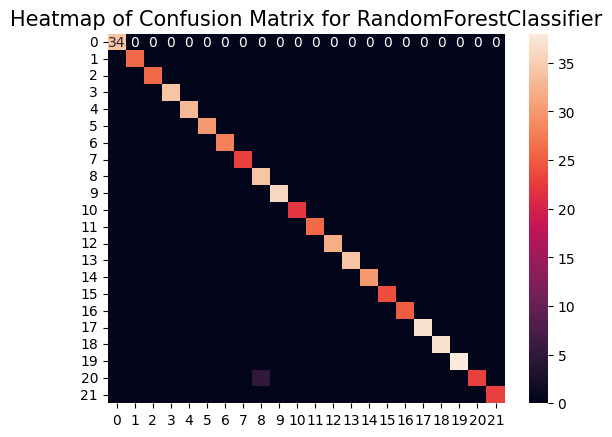

In [69]:
# Model Initializing
from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier()

# Training
random_forest_model.fit(x_train,y_train)

# Testing
random_forest_y_pred = random_forest_model.predict(x_test)

# Accuracy
random_forest_accuracy = accuracy_score(random_forest_y_pred, y_test)
print("Accuracy of Random Forest : ", random_forest_accuracy*100)

# classificatin report
print('The classificatin report for RandomForestClassifier :')
report = classification_report(y_test, random_forest_y_pred)
print(report)

#confustion metrix
cm = confusion_matrix(y_test, random_forest_y_pred)
plt.title('Heatmap of Confusion Matrix for RandomForestClassifier', fontsize = 15)
sns.heatmap(cm, annot = True)
plt.show()

c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy of Logistic Regression :  94.84848484848484
The classificatin report for Logistic Regression :
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        34
      banana       1.00      1.00      1.00        26
   blackgram       0.76      0.85      0.80        26
    chickpea       1.00      1.00      1.00        34
     coconut       1.00      1.00      1.00        33
      coffee       0.97      1.00      0.98        30
      cotton       0.87      0.96      0.92        28
      grapes       1.00      1.00      1.00        23
        jute       0.83      0.88      0.86        34
 kidneybeans       0.97      0.97      0.97        36
      lentil       0.91      0.91      0.91        22
       maize       0.95      0.81      0.88        26
       mango       0.97      1.00      0.98        32
   mothbeans       0.90      0.82      0.86        34
    mungbean       0.94      1.00      0.97        30
   muskmelon       1.00      1.

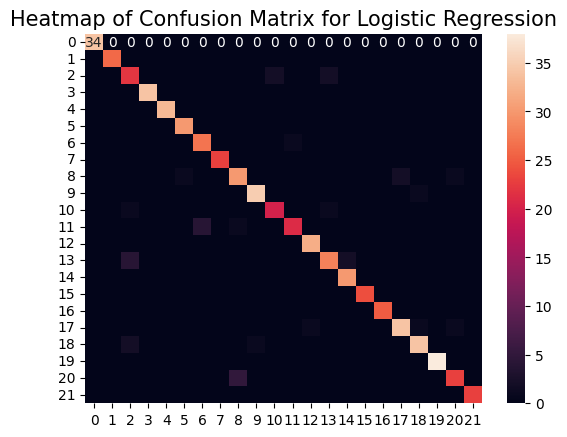

In [70]:
# Model Initializing
from sklearn.linear_model import LogisticRegression
Logistic_Regression_model = LogisticRegression()

# Training
Logistic_Regression_model.fit(x_train,y_train)

# Testing
Logistic_Regression_y_pred = Logistic_Regression_model.predict(x_test)

# Accuracy
Logistic_Regression_accuracy = accuracy_score(Logistic_Regression_y_pred, y_test)
print("Accuracy of Logistic Regression : ", Logistic_Regression_accuracy * 100)

# classificatin report
print('The classificatin report for Logistic Regression :')
report = classification_report(y_test, Logistic_Regression_y_pred)
print(report)

# confustion metrix
cm = confusion_matrix(y_test, Logistic_Regression_y_pred)
plt.title('Heatmap of Confusion Matrix for Logistic Regression', fontsize = 15)
sns.heatmap(cm, annot = True)
plt.show()

Accuracy of MLP Classifier :  95.15151515151516
The classificatin report for MLP Classifier :
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        34
      banana       1.00      1.00      1.00        26
   blackgram       0.85      0.88      0.87        26
    chickpea       1.00      1.00      1.00        34
     coconut       1.00      1.00      1.00        33
      coffee       0.91      1.00      0.95        30
      cotton       0.88      1.00      0.93        28
      grapes       1.00      1.00      1.00        23
        jute       0.90      0.76      0.83        34
 kidneybeans       0.97      0.97      0.97        36
      lentil       0.91      0.91      0.91        22
       maize       1.00      0.81      0.89        26
       mango       0.97      1.00      0.98        32
   mothbeans       0.86      0.91      0.89        34
    mungbean       1.00      1.00      1.00        30
   muskmelon       1.00      1.00      1.

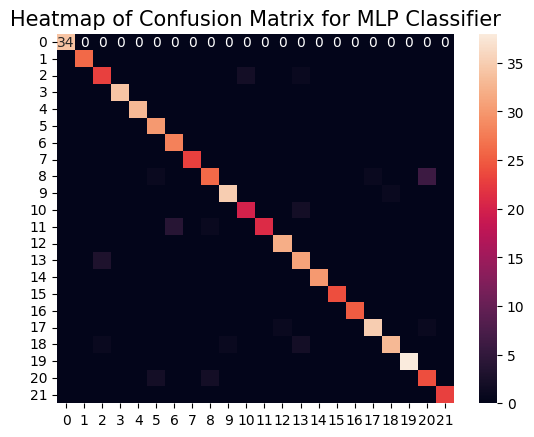

In [71]:
# Model Initializing
from sklearn.neural_network import MLPClassifier
MLP_Classifier_model = MLPClassifier()

# Training
MLP_Classifier_model.fit(x_train,y_train)

# Testing
MLP_Classifier_y_pred = MLP_Classifier_model.predict(x_test)

# Accuracy
MLP_Classifier_accuracy = accuracy_score(MLP_Classifier_y_pred, y_test)
print("Accuracy of MLP Classifier : ", MLP_Classifier_accuracy * 100)

# classificatin report
print('The classificatin report for MLP Classifier :')
report = classification_report(y_test, MLP_Classifier_y_pred)
print(report)

# confustion metrix
cm = confusion_matrix(y_test, MLP_Classifier_y_pred)
plt.title('Heatmap of Confusion Matrix for MLP Classifier', fontsize = 15)
sns.heatmap(cm, annot = True)
plt.show()

Accuracy of SVC Classifier :  96.36363636363636
The classificatin report for SVC Classifier :
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        34
      banana       1.00      1.00      1.00        26
   blackgram       0.93      1.00      0.96        26
    chickpea       1.00      1.00      1.00        34
     coconut       1.00      1.00      1.00        33
      coffee       1.00      0.97      0.98        30
      cotton       0.90      1.00      0.95        28
      grapes       1.00      1.00      1.00        23
        jute       0.76      1.00      0.86        34
 kidneybeans       0.92      1.00      0.96        36
      lentil       0.88      1.00      0.94        22
       maize       1.00      0.88      0.94        26
       mango       1.00      1.00      1.00        32
   mothbeans       1.00      0.91      0.95        34
    mungbean       1.00      1.00      1.00        30
   muskmelon       1.00      1.00      1.

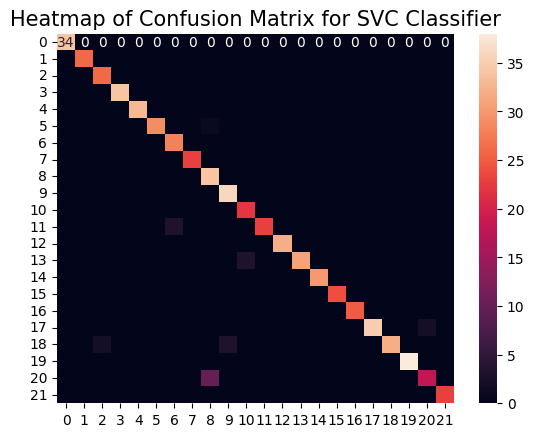

In [72]:
# Model Initializing
from sklearn.svm import SVC
svc_Classifier_model = SVC()

# Training
svc_Classifier_model.fit(x_train,y_train)

# Testing
svc_Classifier_y_pred = svc_Classifier_model.predict(x_test)

# Accuracy
svc_Classifier_accuracy = accuracy_score(svc_Classifier_y_pred, y_test)
print("Accuracy of SVC Classifier : ", svc_Classifier_accuracy * 100)

# classificatin report
print('The classificatin report for SVC Classifier :')
report = classification_report(y_test, svc_Classifier_y_pred)
print(report)

# confustion metrix
cm = confusion_matrix(y_test, svc_Classifier_y_pred)
plt.title('Heatmap of Confusion Matrix for SVC Classifier', fontsize = 15)
sns.heatmap(cm, annot = True)
plt.show()

Accuracy of GNB Classifier :  99.39393939393939
The classificatin report for GNB Classifier :
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        34
      banana       1.00      1.00      1.00        26
   blackgram       1.00      1.00      1.00        26
    chickpea       1.00      1.00      1.00        34
     coconut       1.00      1.00      1.00        33
      coffee       1.00      1.00      1.00        30
      cotton       1.00      1.00      1.00        28
      grapes       1.00      1.00      1.00        23
        jute       0.89      1.00      0.94        34
 kidneybeans       1.00      1.00      1.00        36
      lentil       1.00      1.00      1.00        22
       maize       1.00      1.00      1.00        26
       mango       1.00      1.00      1.00        32
   mothbeans       1.00      1.00      1.00        34
    mungbean       1.00      1.00      1.00        30
   muskmelon       1.00      1.00      1.

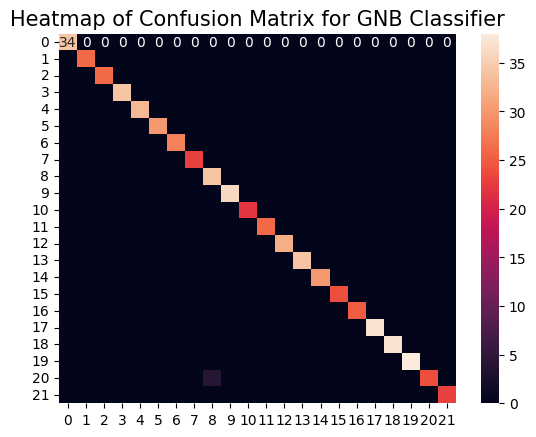

In [73]:
# Model Initializing
from sklearn.naive_bayes import GaussianNB
gnb_Classifier_model = GaussianNB()

# Training
gnb_Classifier_model.fit(x_train,y_train)

# Testing
gnb_Classifier_y_pred = gnb_Classifier_model.predict(x_test)

# Accuracy
gnb_Classifier_accuracy = accuracy_score(gnb_Classifier_y_pred, y_test)
print("Accuracy of GNB Classifier : ", gnb_Classifier_accuracy * 100)

# classificatin report
print('The classificatin report for GNB Classifier :')
report = classification_report(y_test, gnb_Classifier_y_pred)
print(report)

# confustion metrix
cm = confusion_matrix(y_test, gnb_Classifier_y_pred)
plt.title('Heatmap of Confusion Matrix for GNB Classifier', fontsize = 15)
sns.heatmap(cm, annot = True)
plt.show()

Learning rate set to 0.080889
0:	learn: 2.6556847	total: 46.6ms	remaining: 46.5s
1:	learn: 2.2595042	total: 79.5ms	remaining: 39.7s
2:	learn: 2.0027597	total: 111ms	remaining: 36.9s
3:	learn: 1.8014378	total: 140ms	remaining: 34.8s
4:	learn: 1.6340910	total: 171ms	remaining: 34s
5:	learn: 1.4806049	total: 204ms	remaining: 33.9s
6:	learn: 1.3350005	total: 236ms	remaining: 33.5s
7:	learn: 1.2205214	total: 267ms	remaining: 33.1s
8:	learn: 1.1212561	total: 299ms	remaining: 33s
9:	learn: 1.0395556	total: 331ms	remaining: 32.8s
10:	learn: 0.9654087	total: 364ms	remaining: 32.7s
11:	learn: 0.8950405	total: 392ms	remaining: 32.3s
12:	learn: 0.8352933	total: 420ms	remaining: 31.9s
13:	learn: 0.7839126	total: 453ms	remaining: 31.9s
14:	learn: 0.7385772	total: 481ms	remaining: 31.6s
15:	learn: 0.6891675	total: 509ms	remaining: 31.3s
16:	learn: 0.6477212	total: 538ms	remaining: 31.1s
17:	learn: 0.6129718	total: 569ms	remaining: 31s
18:	learn: 0.5778861	total: 601ms	remaining: 31s
19:	learn: 0.5482

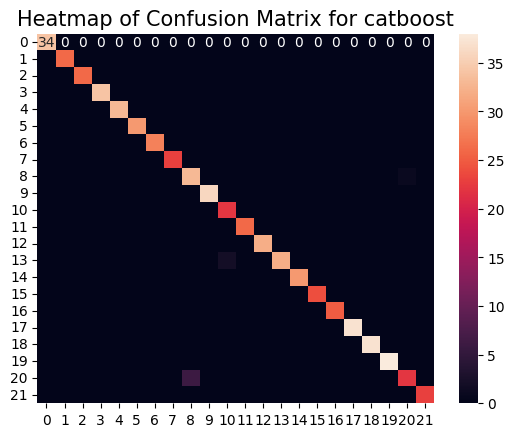

In [74]:
# Model Initializing
from catboost import CatBoostClassifier
catboost_model = CatBoostClassifier()

# Training
catboost_model.fit(x_train,y_train)

# Testing
catboost_y_pred = catboost_model.predict(x_test)

# Accuracy
catboost_accuracy = accuracy_score(catboost_y_pred, y_test)
print("Accuracy of catboost : ", catboost_accuracy * 100)

# classificatin report
print('The classificatin report for catboost :')
report = classification_report(y_test, catboost_y_pred)
print(report)

# confustion metrix
cm = confusion_matrix(y_test, catboost_y_pred)
plt.title('Heatmap of Confusion Matrix for catboost', fontsize = 15)
sns.heatmap(cm, annot = True)
plt.show()

## Model Comparision

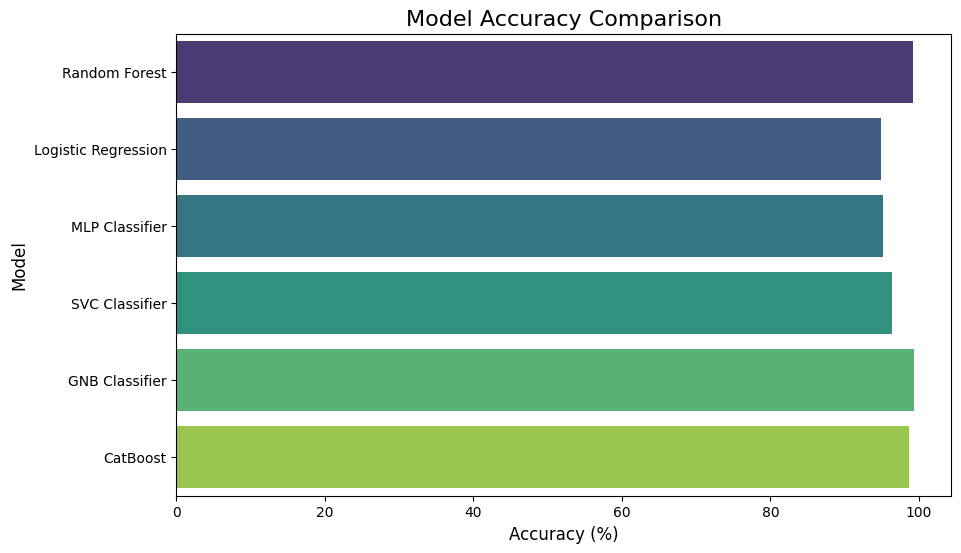

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# Collect the model names and their respective accuracies
models = ['Random Forest', 'Logistic Regression', 'MLP Classifier', 'SVC Classifier', 
          'GNB Classifier', 'CatBoost']
accuracies = [random_forest_accuracy * 100, 
              Logistic_Regression_accuracy * 100, 
              MLP_Classifier_accuracy * 100, 
              svc_Classifier_accuracy * 100, 
              gnb_Classifier_accuracy * 100, 
              catboost_accuracy * 100]

# Create a DataFrame for the model comparison
model_comparison_df = pd.DataFrame({'Model': models, 'Accuracy': accuracies})

# Plot the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=model_comparison_df, palette='viridis')
plt.title('Model Accuracy Comparison', fontsize=16)
plt.xlabel('Accuracy (%)', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.show()

## Save model

In [76]:
# Save the trained models
import joblib

joblib.dump(random_forest_model, 'Models/random_forest_model.pkl')
joblib.dump(Logistic_Regression_model, 'Models/logistic_regression_model.pkl')
joblib.dump(MLP_Classifier_model, 'Models/mlp_classifier_model.pkl')
joblib.dump(svc_Classifier_model, 'Models/svc_classifier_model.pkl')
joblib.dump(gnb_Classifier_model, 'Models/gnb_classifier_model.pkl')
joblib.dump(catboost_model, 'Models/catboost_model.pkl')

['Models/catboost_model.pkl']

## Prediction Part

In [78]:
import joblib
import numpy as np
import pandas as pd

model = joblib.load(r'Models\gnb_classifier_model.pkl')

def get_user_input_and_predict(input_data):
    user_input = np.array([input_data])
    prediction = model.predict(user_input)
    print(f"The predicted crop type is: {prediction[0]}")

### Example predictions

In [79]:
get_user_input_and_predict([90, 42, 43, 20.88, 82, 6.5, 202.94])

The predicted crop type is: rice


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [80]:
get_user_input_and_predict([61, 41, 17, 25.14, 65.26, 6.02, 76.68])

The predicted crop type is: maize


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [81]:
get_user_input_and_predict([32, 73, 81, 20.45, 15.4, 5.99, 92.68])

The predicted crop type is: chickpea


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [82]:
get_user_input_and_predict([22, 79, 17, 21.42, 20.4, 5.91, 116.52])

The predicted crop type is: kidneybeans


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [83]:
get_user_input_and_predict([3, 60, 19, 25.75, 40.72, 4.82, 100.78])

The predicted crop type is: pigeonpeas


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [84]:
get_user_input_and_predict([9, 49, 16, 30.88, 41.37, 7.66, 55.05])

The predicted crop type is: mothbeans


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [85]:
get_user_input_and_predict([2, 39, 15, 28.07, 82.91, 6.48, 49.62])

The predicted crop type is: mungbean


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [86]:
get_user_input_and_predict([20, 68, 23, 25.55, 63.95, 7.71, 63.18])

The predicted crop type is: blackgram


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [87]:
get_user_input_and_predict([19, 72, 15, 28.84, 69.76, 6.89, 44.09])

The predicted crop type is: lentil


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [88]:
get_user_input_and_predict([28, 6, 40, 22.11, 91.34, 6.77, 106.87])

The predicted crop type is: pomegranate


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [89]:
get_user_input_and_predict([92, 81, 52, 27.39, 81.47, 6.44, 94.31])

The predicted crop type is: banana


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [90]:
get_user_input_and_predict([28, 37, 28, 32.13, 50.53, 6.1, 98.63])

The predicted crop type is: mango


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [91]:
get_user_input_and_predict([32, 129, 201, 16.36, 83, 6.49, 71.56])

The predicted crop type is: grapes


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [92]:
get_user_input_and_predict([105, 14, 50, 26.21, 87.69, 6.42, 59.66])

The predicted crop type is: watermelon


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [93]:
get_user_input_and_predict([84, 29, 49, 29.94, 93.91, 6.25, 20.39])

The predicted crop type is: muskmelon


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [94]:
get_user_input_and_predict([19, 122, 202, 23.34, 90.38, 5.81, 112.9])

The predicted crop type is: apple


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [95]:
get_user_input_and_predict([33, 15, 7, 15.83, 91.68, 7.65, 109.76])

The predicted crop type is: orange


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [96]:
get_user_input_and_predict([44, 57, 53, 42.3, 90.51, 6.93, 74.88])

The predicted crop type is: papaya


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [97]:
get_user_input_and_predict([14, 23, 25, 26.19, 96.97, 5.61, 135.42])

The predicted crop type is: coconut


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [98]:
get_user_input_and_predict([117, 51, 15, 22.95, 78.72, 6.04, 99.75])

The predicted crop type is: cotton


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [99]:
get_user_input_and_predict([100, 58, 41, 23.17, 87.88, 6.66, 160.62])

The predicted crop type is: jute


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [ ]:
get_user_input_and_predict([113, 33, 34, 33, 62.14, 6.56, 153.48])

The predicted crop type is: coffee


c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
